Dylan Ross

Prepare design matrices
- null design
- design based on correlation between component 0 from single-block PLS-DA

## Setup

### Imports

In [23]:
import os
import pickle

import polars as pl
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score
import numpy as np

from plsda import PLSDAClassifier

### Constants

In [24]:
# Jupyter server should be running from src/python
CACHE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_cache",
)

## Prepare design matrices
### Utility function to create null design matrix

In [25]:
def create_null_design_matrix(
    subset_id: str
) :
    blocks = pl.read_ipc(
        os.path.join(CACHE_DIR, f"{subset_id}.arrow")
    )["Block"].unique()
    pl.DataFrame({
        "": blocks,
        **{col: [0] * len(blocks) for col in blocks}  
    }).write_csv(
        os.path.join(
            CACHE_DIR,
            "diablo",
            f"{subset_id}_null-design.csv"
        )
    )

### Utility functions to create a design matrix based on single-block PLS-DA 

In [26]:
def plot_confusion_matrix(y, y_pred, figname=None):
    fig, ax = plt.subplots(figsize=(2, 2))
    ConfusionMatrixDisplay.from_predictions(y, y_pred, ax=ax)
    if figname is not None:
        plt.savefig(figname, dpi=400, bbox_inches="tight", transparent=True)
    plt.show()
    plt.close()

In [27]:
def plot_plsda_projections(projections, y, y_pred, figname=None):
    y_to_color = {
        0.: "#000088",
        1.: "#880000"
    }
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.axvline(0, ls="--", c="k", lw=0.5, zorder=-1)
    ax.axhline(0, ls="--", c="k", lw=0.5, zorder=-1)
    for c0, c1, yt, yp in zip(*projections, y, y_pred):
        correct = yt == yp
        ax.scatter(
            c0, 
            c1,
            c="#00000000" if correct else y_to_color[yt],
            marker="o" if correct else "x",
            s=24,
            edgecolors=y_to_color[yt] if correct else "none",
            linewidths=1.
        )
    for d in ["top", "right", "bottom", "left"]:
        ax.spines[d].set_visible(False)
    ax.set_xlabel("component 0")
    ax.set_ylabel("component 1")
    if figname is not None:
        plt.savefig(figname, dpi=400, bbox_inches="tight", transparent=True)
    plt.show()
    plt.close()

In [28]:
def display_and_return_block_corr_mat(block_projections):
    corr = pd.DataFrame(block_projections).corr().abs()
    # set the diagonal to 0
    for i in range(min(len(corr), len(corr.columns))):
        corr.iloc[i, i] = 0
    display(
        corr
        .style.background_gradient(
            cmap='binary', 
            vmin=0, 
            vmax=1
        )
        .format(precision=1)
    )
    return corr

In [29]:
def create_plsda_design_matrix(subset_id): 
    # load subset sample columns
    with open(os.path.join(CACHE_DIR, f"{subset_id}_cols.pkl"), "rb") as pf:
        wt_cols, mut_cols = pickle.load(pf)
    # load the omics data subset
    omics_subset = pl.read_ipc(os.path.join(CACHE_DIR, f"{subset_id}.arrow"))
    block_projections = {}
    # train PLS-DA model on each block
    for block in omics_subset["Block"].unique():
        print(f"--- {block} ---")
        X = (
            omics_subset
            .filter(pl.col("Block") == block)
            .drop("Block", "Feature")
            .to_numpy()
            .T
        )
        y = np.concatenate([
            np.zeros(len(wt_cols)),
            np.ones(len(mut_cols)),
        ])
        model = PLSDAClassifier(scale=False, max_iter=10_000)
        model.fit(X, y)
        y_pred = model.predict(X)
        auc = roc_auc_score(y, model.predict_proba(X)[:,1])
        print(f"ROC AUC: {auc:.4f}")
        plot_confusion_matrix(y, y_pred)
        projections = model.transform(X).T
        plot_plsda_projections(projections, y, y_pred)
        block_projections[block] = projections[0]
    # display the final block correlations for component 0 
    # (the design matrix)
    design = display_and_return_block_corr_mat(block_projections)
    design.to_csv(
        os.path.join(
            CACHE_DIR,
            "diablo",
            f"{subset_id}_plsda-design.csv"
        )
    )

### NPM1 vs. WT

#### Black patients

In [30]:
create_null_design_matrix("B_NPM1-WT")

--- Lipidomics ---
ROC AUC: 0.9039


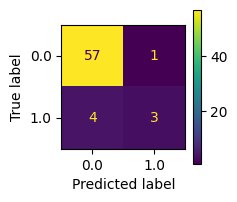

/var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_47167/3282521268.py:11: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


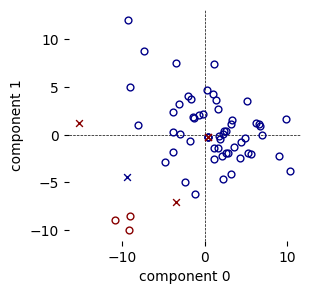

--- Metabolomics ---
ROC AUC: 0.9187


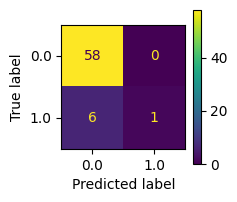

/var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_47167/3282521268.py:11: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


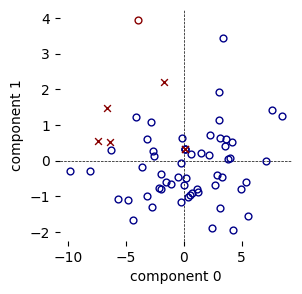

--- Phosphoproteomics ---
ROC AUC: 0.8916


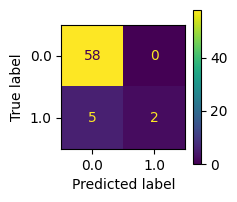

/var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_47167/3282521268.py:11: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


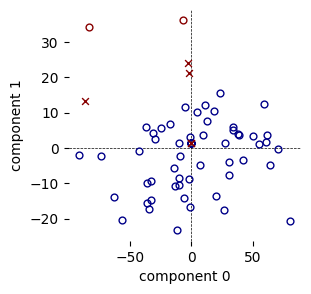

--- Proteomics ---
ROC AUC: 0.8596


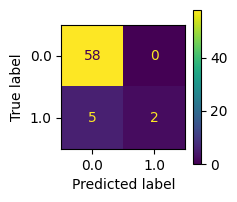

/var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_47167/3282521268.py:11: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


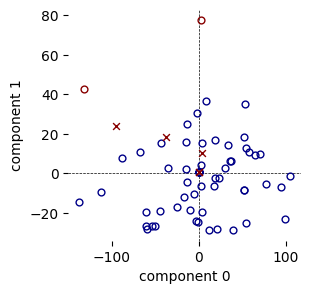

,Lipidomics,Metabolomics,Phosphoproteomics,Proteomics
Lipidomics,0.0,0.7,0.2,0.3
Metabolomics,0.7,0.0,0.4,0.5
Phosphoproteomics,0.2,0.4,0.0,0.9
Proteomics,0.3,0.5,0.9,0.0


In [31]:
create_plsda_design_matrix("B_NPM1-WT")

#### White patients

In [32]:
create_null_design_matrix("W_NPM1-WT")

--- Phosphoproteomics ---
ROC AUC: 0.9956


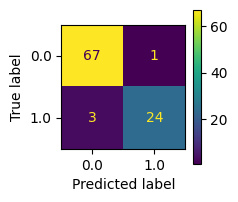

/var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_47167/3282521268.py:11: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


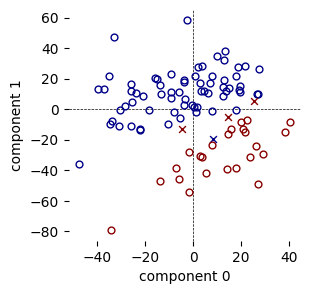

--- Transcriptomics ---
ROC AUC: 0.9510


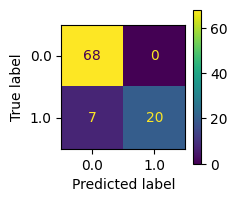

/var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_47167/3282521268.py:11: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


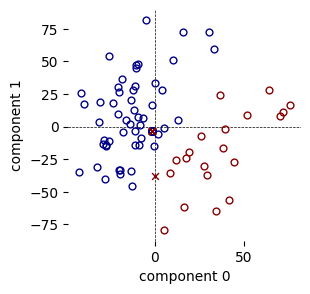

--- Proteomics ---
ROC AUC: 0.9875


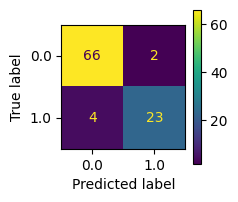

/var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_47167/3282521268.py:11: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


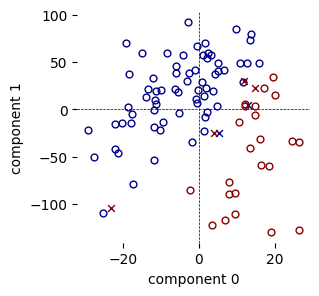

,Phosphoproteomics,Transcriptomics,Proteomics
Phosphoproteomics,0.0,0.3,0.9
Transcriptomics,0.3,0.0,0.5
Proteomics,0.9,0.5,0.0


In [33]:
create_plsda_design_matrix("W_NPM1-WT")

### NRAS vs. WT

#### Black patients

In [34]:
create_null_design_matrix("B_NRAS-WT")

--- Acetylomics ---
ROC AUC: 0.9881


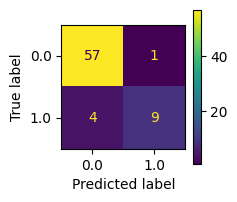

/var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_47167/3282521268.py:11: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


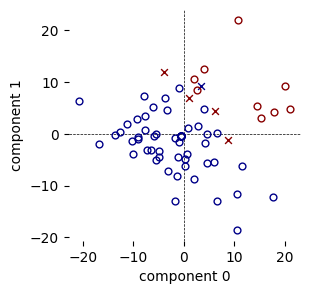

--- Metabolomics ---
ROC AUC: 0.8263


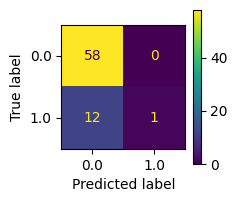

/var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_47167/3282521268.py:11: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


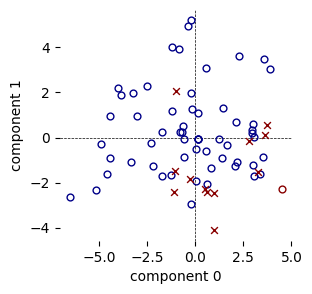

--- Phosphoproteomics ---
ROC AUC: 0.8979


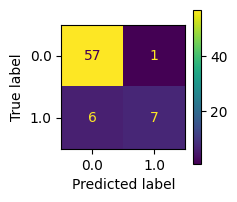

/var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_47167/3282521268.py:11: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


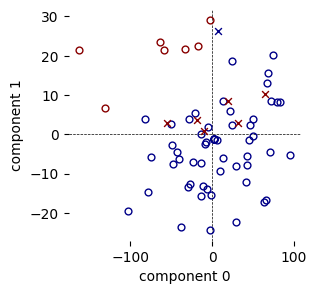

--- Proteomics ---
ROC AUC: 0.8767


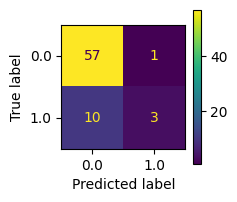

/var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_47167/3282521268.py:11: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


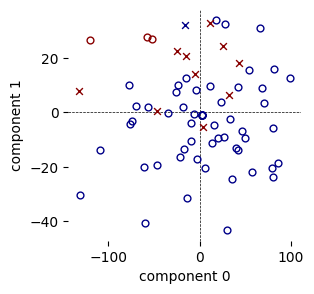

--- Lipidomics ---
ROC AUC: 0.9708


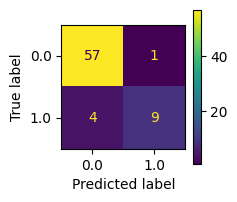

/var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_47167/3282521268.py:11: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


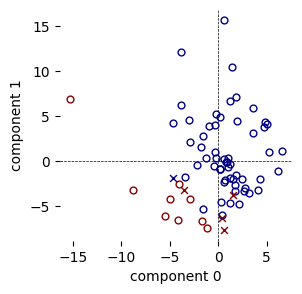

,Acetylomics,Metabolomics,Phosphoproteomics,Proteomics,Lipidomics
Acetylomics,0.0,0.3,0.4,0.3,0.4
Metabolomics,0.3,0.0,0.2,0.3,0.5
Phosphoproteomics,0.4,0.2,0.0,0.9,0.2
Proteomics,0.3,0.3,0.9,0.0,0.1
Lipidomics,0.4,0.5,0.2,0.1,0.0


In [35]:
create_plsda_design_matrix("B_NRAS-WT")

#### White patients

In [36]:
create_null_design_matrix("W_NRAS-WT")

--- Phosphoproteomics ---
ROC AUC: 0.9097


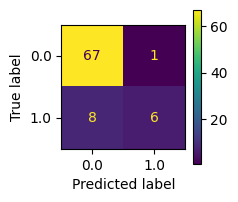

/var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_47167/3282521268.py:11: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


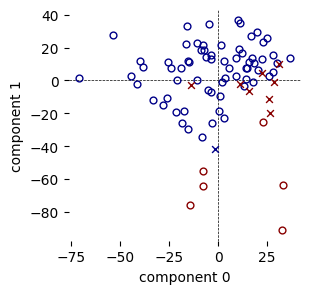

--- Transcriptomics ---
ROC AUC: 0.8535


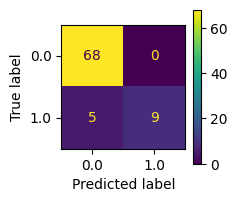

/var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_47167/3282521268.py:11: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


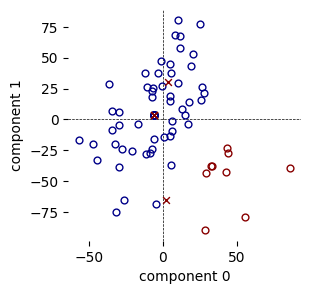

--- Proteomics ---
ROC AUC: 0.7973


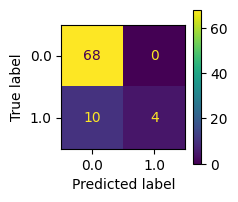

/var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_47167/3282521268.py:11: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


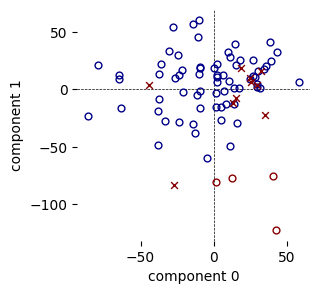

,Phosphoproteomics,Transcriptomics,Proteomics
Phosphoproteomics,0.0,0.2,0.9
Transcriptomics,0.2,0.0,0.1
Proteomics,0.9,0.1,0.0


In [37]:
create_plsda_design_matrix("W_NRAS-WT")